# Analysis of Performance Density vs top performances over the years and in different age groups

Hypothesis: 
- H_0 ->  Performance Density in a discipline is **not changed** to  top performances over the years
- H_1 -> Performance Density in a Discipline is **changed** from top performances over the years

In [1]:
from lib import util
import pandas as pd
import numpy as np
import lib.plotting_style as plt
import seaborn as sns
import help_functions as hp


data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv') 

data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv'

### Definitions 

Pre - notes:
- Not always top 50, sometimes there are less 

- **Top performance (topPerf)**:
    - Can be Top-1 -> Too sensitive to Outlier Performances
    - Top-3 are a good representive of the elite (Top performances). 
    - Maybe another measurement? -> In some years/discipline the elite is more dense than in others
- **Relative Gap per Athlete (relGapAth)**: Relative Gap of an Athlete i to topPerf:

    $\text{relGapAth}_{i,y} = \frac{P_{i,year} - P_{\text{topPerf},year}}{P_{\text{topPerf},year}}$
- **Performance Density (PerfDens)**: Always taking the Top 30 as reference for comparison between disciplines and with years/disciplines with less than 50 entries.

In [2]:
disciplines = data["disziplin"].unique()
disciplines

array(['100 m', '200 m', '400 m', '800 m', '1500 m', '3000 m', '5000 m',
       '10 km', 'Halbmarathon', 'Marathon', '100 km', '100 m Huerden',
       '400 m Huerden', '3000 m Hindernis', 'Hochsprung',
       'Stabhochsprung', 'Weitsprung', 'Dreisprung', 'Kugelstoss',
       'Diskuswurf', 'Hammerwurf', 'Speerwurf', '5000 m Gehen',
       '10 km Gehen', '20 km Gehen', '110 m Huerden', '2000 m Hindernis',
       '300 m', '1000 m', '5 km', '3000 m Gehen', '50 km Gehen', '2000 m',
       '10 000 m Gehen', '1500 m Hindernis', '10 000 m', 'Siebenkampf',
       'Zehnkampf'], dtype=object)

In [3]:
suff_entries = 25
top_performances = 3  # top N adults per year for mean top performance

"""
Exluded for now: '100 km', '100 m Huerden',
       '400 m Huerden', '3000 m Hindernis', '5000 m Gehen',
       '10 km Gehen', '20 km Gehen', '110 m Huerden', '2000 m Hindernis',
       '300 m', '1000 m', '5 km', '3000 m Gehen', '50 km Gehen', '2000 m',
       '10 000 m Gehen', '1500 m Hindernis', '10 000 m', 'Marathon', '10 km', 'Halbmarathon', '800 m', '3000 m'


"""
data = data.copy()
data["leistung"] = pd.to_numeric(data["leistung"], errors="coerce")  # invalid -> NaN
data = data.dropna(subset=["leistung"])
# Map disciplines to track vs field
track_disciplines = ['100 m', '200 m', '400 m', '1500 m', '5000 m']  # example, adjust
field_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung',
                     'Kugelstoss', 'Diskuswurf', 'Hammerwurf', 'Speerwurf']

disciplines = track_disciplines + field_disciplines  

results = []

results = []

for disc in disciplines:
    is_track = disc in track_disciplines

    for gender in ["M", "W"]:

        # -------------------------------
        # 1) Adult data for the reference
        # -------------------------------
        adult_data = data[
            (data["disziplin"] == disc) &
            (data["geschlecht"] == gender) &
            (data["altersklasse"].isin(["Maenner", "Frauen"]))
        ]

        if adult_data.empty or adult_data["jahr"].value_counts().min() < suff_entries:
            continue

        mean_topPerf = hp.get_top_data(
            adult_data,
            top_performances,
            smoothing=3,
            track_discipline=is_track
        )

        # -------------------------------
        # 2) Loop over age groups
        # -------------------------------
        age_groups = data["altersklasse"].unique()

        for ag in age_groups:

            ag_data = data[
                (data["disziplin"] == disc) &
                (data["geschlecht"] == gender) &
                (data["altersklasse"] == ag)
            ].copy()

            if ag_data.empty:
                continue

            # compute relative gap
            ag_data = hp.compute_relative_gap(ag_data, mean_topPerf)

            if is_track:
                ag_data["relGapAth"] = -ag_data["relGapAth"]

            # ---------------------------------------
            # NEW: Keep only years with ≥ 25 entries
            # ---------------------------------------
            valid_years = ag_data["jahr"].value_counts()
            valid_years = valid_years[valid_years >= suff_entries].index

            ag_data = ag_data[ag_data["jahr"].isin(valid_years)]

            if ag_data.empty:
                continue

            # ---------------------------------------
            # per valid year: top 25 of that age group
            # ---------------------------------------
            ag_top25 = (
                ag_data.sort_values(["jahr", "relGapAth"], ascending=False)
                       .groupby("jahr")
                       .head(suff_entries)
            )

            results.append(ag_top25)

df_all_disciplines_gender = pd.concat(results, ignore_index=True)


# Combine all results into one DataFrame
df_all_disciplines_gender = pd.concat(results, ignore_index=True)


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\perfDensityVStopPerformance\help_functions.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topPerf = data.groupby("jahr", group_keys=False).apply(
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\perfDensityVStopPerformance\help_functions.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topPerf = data.groupby("jahr

Calculation of relative Distance per athlete

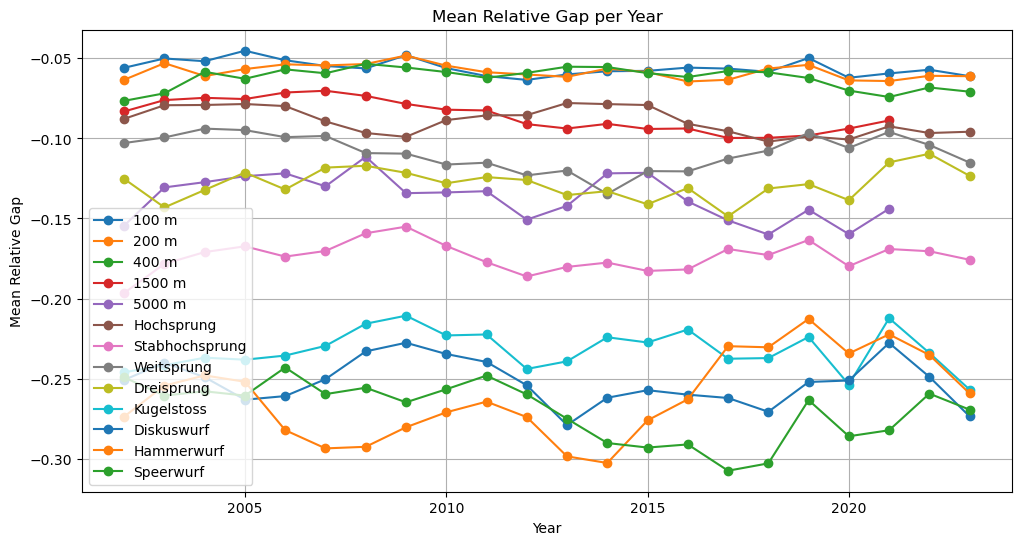

In [ ]:
import lib.plotting_style as plt

def plot_mean_relGap_per_year(df, title="Mean Relative Gap per Year"):
    """
    Plots mean relative gap per year for all disciplines in the dataframe.
    """
    plt.figure(figsize=(12, 6))
    
    for disc in disciplines:
        df_disc = df[df["disziplin"] == disc]
        mean_relGap_per_year = df_disc.groupby("jahr")["relGapAth"].mean()
        plt.plot(mean_relGap_per_year.index, mean_relGap_per_year.values, marker='o', label=disc)
    
    plt.xlabel("Year")
    plt.ylabel("Mean Relative Gap")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Usage
plot_mean_relGap_per_year(df_all_disciplines_gender[df_all_disciplines_gender["altersklasse"]=="20"])


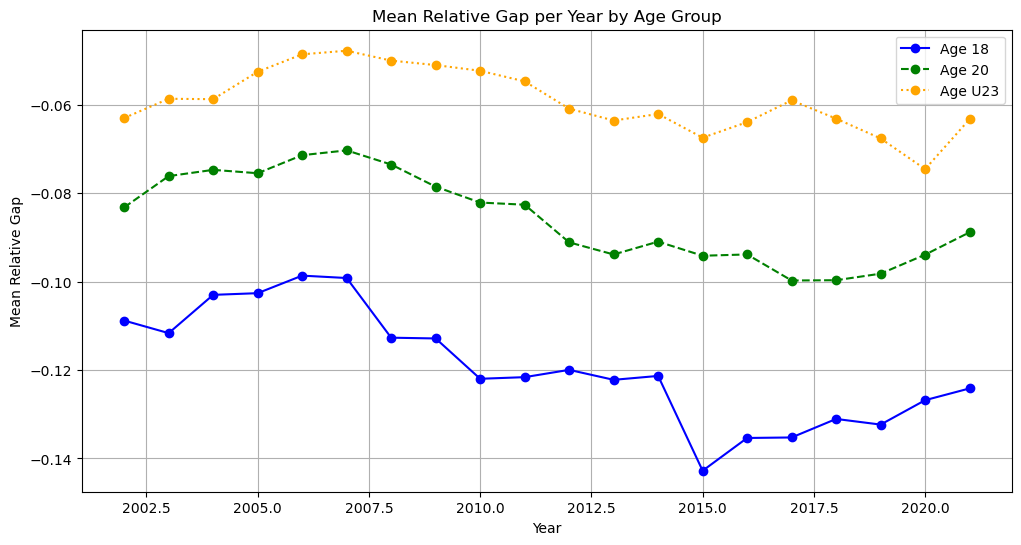

In [ ]:
import lib.plotting_style as plt

def plot_mean_relGap_per_year_agegroups(df, age_groups=["18", "20", "U23"], title="Mean Relative Gap per Year by Age Group"):
    """
    Plots mean relative gap per year for selected age groups, aggregated across all disciplines.
    """
    plt.figure(figsize=(12, 6))


    # Define line styles or colors for different age groups
    age_styles = {"18": "solid", "20": "dashed", "U23": "dotted"}
    age_colors = {"18": "blue", "20": "green", "U23": "orange"}

    for ag in age_groups:
        df_ag = df[df["altersklasse"] == ag]
        if df_ag.empty:
            continue
        mean_relGap_per_year = df_ag.groupby("jahr")["relGapAth"].mean()
        plt.plot(mean_relGap_per_year.index, mean_relGap_per_year.values,
                marker='o', linestyle=age_styles.get(ag, "solid"),
                color=age_colors.get(ag, "black"),
                label=f"Age {ag}")

    plt.xlabel("Year")
    plt.ylabel("Mean Relative Gap")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Usage

plot_mean_relGap_per_year_agegroups(df_all_disciplines_gender[df_all_disciplines_gender["disziplin"] == "1500 m"], age_groups=["16", "18", "20", "U23"])



## Can we see something out of that?

I think it is too dependend on the current best - maybe the depth could be analysed differently and more easily - absolute std and mean maybe

In [51]:
import pandas as pd

def compute_tiers(df, top_n_list=[3, 7, 9, 10]):
    """
    Computes mean performance for top N tiers:
    top_n_list = [3, 7, 9, 10] means:
        - Top 3
        - Next 4–10 (7)
        - Next 11–19 (9)
        - Next 20–29 (10)
    Returns a DataFrame with discipline, age group, year, tier, mean and std.
    """
    results = []
    
    for disc in df["disziplin"].unique():
        for ag in df["altersklasse"].unique():
            df_sub = df[(df["disziplin"] == disc) & (df["altersklasse"] == ag)]
            for year, group in df_sub.groupby("jahr"):
                group_sorted = group.sort_values("leistung", ascending=True).reset_index(drop=True)
                start_idx = 0
                for i, n in enumerate(top_n_list):
                    tier_name = f"{start_idx+1}-{start_idx+n}"
                    tier_data = group_sorted.iloc[start_idx:start_idx+n]
                    if not tier_data.empty:
                        results.append({
                            "disziplin": disc,
                            "altersklasse": ag,
                            "jahr": year,
                            "tier": tier_name,
                            "mean": tier_data["leistung"].mean(),
                            "std": tier_data["leistung"].std()
                        })
                    start_idx += n
    return pd.DataFrame(results)

tiers_df = compute_tiers(df_all_disciplines_gender)



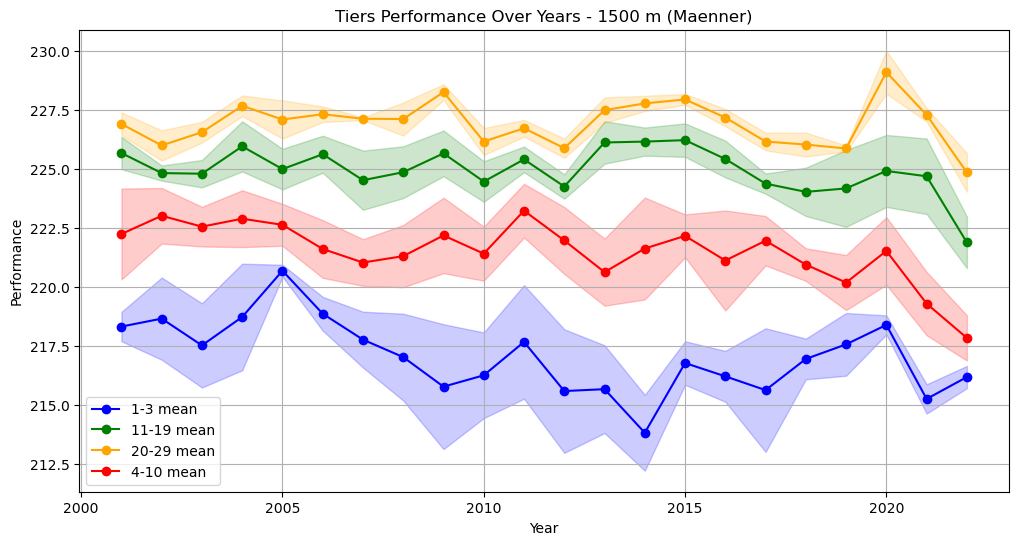

In [ ]:
import lib.plotting_style as plt

def plot_tiers_for_discipline(tiers_df, discipline, age_group=None):
    """
    Plots mean performance per tier over years for a specific discipline.
    
    Parameters:
        tiers_df: DataFrame with 'disziplin', 'altersklasse', 'jahr', 'tier', 'mean', 'std'
        discipline: str, the discipline to plot
        age_group: str, optional, to filter by age group
    """
    df_plot = tiers_df[tiers_df["disziplin"] == discipline]
    
    if age_group:
        df_plot = df_plot[df_plot["altersklasse"] == age_group]
    
    plt.figure(figsize=(12, 6))
    
    tiers = df_plot["tier"].unique()
    colors = ["blue", "green", "orange", "red"]  # one color per tier
    
    for i, tier in enumerate(sorted(tiers)):
        df_tier = df_plot[df_plot["tier"] == tier].sort_values("jahr")
        plt.plot(df_tier["jahr"], df_tier["mean"], marker='o', color=colors[i], label=f"{tier} mean")
        plt.fill_between(df_tier["jahr"], 
                         df_tier["mean"] - df_tier["std"], 
                         df_tier["mean"] + df_tier["std"], 
                         color=colors[i], alpha=0.2)
    
    plt.xlabel("Year")
    plt.ylabel("Performance")
    title = f"Tiers Performance Over Years - {discipline}"
    if age_group:
        title += f" ({age_group})"
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Usage example
plot_tiers_for_discipline(tiers_df, discipline="1500 m", age_group="Maenner")
